# Maternal Health Risk Stratification
### Statistical classification and model evaluation with Python

This notebook examines how six recorded physiological measurements differ across Low Risk, Mid Risk, and High Risk groups. It also evaluates a simple multinomial Logistic Regression model and examines where that model makes mistakes.

The analysis begins with the data itself: missing values, repeated rows, unusual measurements, and class balance are reviewed before any model is fitted. Results are then reported by class rather than by accuracy alone.

> **Scope:** This is an educational statistical analysis. The fitted model is not intended for diagnosis, treatment decisions, or clinical triage.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

RANDOM_STATE = 42


## 1. Data loading

The file contains six predictors: Age, SystolicBP, DiastolicBP, BS, BodyTemp, and HeartRate. RiskLevel is the three category outcome used in the classification analysis.


In [2]:
DATA_FILE = "Maternal Health Risk Data Set.csv"

candidate_paths = [
    Path("data") / DATA_FILE,
    Path("..") / "data" / DATA_FILE,
    Path(DATA_FILE),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place 'Maternal Health Risk Data Set.csv' in the data/ folder "
        "or next to the notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH.resolve()}")


Loaded dataset from: /mnt/data/Maternal Health Risk Data Set.csv


## 2. Initial data review

Before modeling, the file is checked for its dimensions, variable types, missing values, repeated rows, class frequencies, and measurements that may be physiologically implausible.


In [3]:
df.head()



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
df.shape



(1014, 7)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [6]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
df.isna().sum()


Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(562)

### Findings from the initial data review

- The raw file contains **1,014 observations and 7 variables**.
- No missing values were found.
- The file contains **562 exact repeated rows**.
- Two observations have **HeartRate = 7 bpm**. These values were excluded because they are not physiologically plausible for the population represented in this dataset.
- The minimum recorded age is **10 years**. These younger observations were kept because the available data do not provide enough evidence to treat them as recording errors.

The dataset has no patient identifier. For that reason, an exact repeated row cannot be confirmed as a repeated record from the same person. Removing repeated rows in the primary analysis is therefore a methodological choice, and its effect is examined later in a separate sensitivity analysis.


In [9]:
df["RiskLevel"].value_counts()


RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [10]:
df["RiskLevel"].value_counts(normalize=True)*100

RiskLevel
low risk     40.039448
mid risk     33.136095
high risk    26.824458
Name: proportion, dtype: float64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


In [12]:
df[df["Age"] <= 15].sort_values("Age")

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
19,10,70,50,6.9,98.0,70,low risk
250,10,85,65,6.9,98.0,70,low risk
849,10,100,50,6.0,99.0,70,mid risk
670,10,100,50,6.0,99.0,70,mid risk
155,12,95,60,7.5,98.0,65,low risk
...,...,...,...,...,...,...,...
886,15,76,49,6.8,98.0,77,low risk
880,15,76,49,6.8,98.0,77,low risk
881,15,120,80,6.8,98.0,70,low risk
927,15,78,49,7.5,98.0,77,low risk


In [13]:
df[df["HeartRate"] <= 55 ].sort_values("HeartRate")

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [14]:
# Frequency of Age values
df["Age"].value_counts().sort_index()

Age
10     4
12    35
13    12
14     3
15    60
16    16
17    63
18    19
19    67
20    22
21    38
22    45
23    71
24     3
25    48
26     3
27     9
28    28
29    40
30    30
31    22
32    48
33     5
34     5
35    50
36     4
37     6
38     2
39     4
40    37
41     1
42    23
43     5
44     3
45     9
46     1
48    26
49     9
50    43
51     1
54    12
55    37
56     1
59     2
60    34
62     1
63     2
65     3
66     1
70     1
Name: count, dtype: int64

In [15]:
# Exact repeated rows
df[df.duplicated(keep=False)].sort_values(
    ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "RiskLevel" ]
).head(30)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
552,12,90,60,7.5,102.0,60,low risk
940,12,90,60,7.5,102.0,60,low risk
543,12,90,60,7.5,102.0,66,low risk
934,12,90,60,7.5,102.0,66,low risk
588,12,90,60,7.5,102.0,66,mid risk
827,12,90,60,7.5,102.0,66,mid risk
171,12,90,60,7.9,102.0,66,high risk
963,12,90,60,7.9,102.0,66,high risk


In [16]:
df[df.duplicated(keep=False)].groupby(
    ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "RiskLevel"]
).size().sort_values(ascending=False).head(20)

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
55   140         95           19.0  98.0      77         high risk    10
40   160         100          19.0  98.0      77         high risk    10
54   140         100          15.0  98.0      66         high risk     9
32   140         90           18.0  98.0      88         high risk     9
40   120         95           11.0  98.0      80         high risk     7
31   120         60           6.1   98.0      76         low risk      7
32   120         90           7.5   98.0      70         low risk      7
42   120         80           7.5   98.0      70         low risk      7
19   120         80           7.0   98.0      70         low risk      7
29   130         70           7.5   98.0      78         

## 3. Data preparation

A copy of the original dataframe is kept before any changes are made. The primary modeling dataset is prepared in three steps:

1. exclude the two observations with HeartRate equal to 7 bpm;
2. remove exact repeated rows;
3. reset the dataframe index.

Removing repeated rows reduces the chance that identical records are represented in both training and test data. Because patient identifiers are unavailable, this step is reported as an assumption rather than as proof that the repeated rows were errors.


In [17]:
df_raw = df.copy()


In [18]:
df_clean = df_raw[df_raw["HeartRate"]!= 7].copy()

In [19]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


In [20]:
print(type(df_clean))
print("Original shape:", df_raw.shape)
print("Cleaned shape:", df_clean.shape)
print("Remaining duplicates:", df_clean.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Original shape: (1014, 7)
Cleaned shape: (451, 7)
Remaining duplicates: 0


### Result of preprocessing

The primary modeling dataset contains **451 observations**. HeartRate equal to 7 has been excluded, and no exact repeated rows remain in this version of the data.


In [21]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,451.0,29.223947,13.768594,10.0,19.0,25.0,35.0,70.0
SystolicBP,451.0,110.532151,17.886574,70.0,90.0,120.0,120.0,160.0
DiastolicBP,451.0,75.419069,13.769838,49.0,65.0,80.0,87.0,100.0
BS,451.0,8.347162,2.832273,6.0,6.9,7.5,7.9,19.0
BodyTemp,451.0,98.694013,1.412086,98.0,98.0,98.0,98.0,103.0
HeartRate,451.0,74.097561,7.530045,60.0,70.0,76.0,80.0,90.0


In [22]:
df_clean.isna().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

## 4. Q1: What does the sample look like?

The first question describes the RiskLevel distribution after preprocessing. It also checks whether removing repeated rows changes the class proportions and whether identical predictor profiles are linked to different RiskLevel labels.


In [23]:
df_clean["RiskLevel"].value_counts(normalize=True)*100

RiskLevel
low risk     51.662971
high risk    24.833703
mid risk     23.503326
Name: proportion, dtype: float64

In [24]:
risk_summary = pd.DataFrame({
    "Count": df_clean["RiskLevel"].value_counts(),
    "Percent": (
        df_clean["RiskLevel"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    ),
})

risk_summary


,Count,Percent
RiskLevel,,
low risk,233,51.7
high risk,112,24.8
mid risk,106,23.5


In [25]:
raw_distribution = df_raw["RiskLevel"].value_counts(normalize=True).mul(100).round(1)

clean_distribution = df_clean["RiskLevel"].value_counts(normalize=True).mul(100).round(1)

comparison = pd.DataFrame({
    "Raw %": raw_distribution,
    "Clean %": clean_distribution
})

comparison

,Raw %,Clean %
RiskLevel,,
high risk,26.8,24.8
low risk,40.0,51.7
mid risk,33.1,23.5


In [26]:
features = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicting_labels = (
    df_clean
    .groupby(features)["RiskLevel"]
    .nunique()
)

conflicting_labels = conflicting_labels[conflicting_labels > 1]

print("Number of identical feature combinations with conflicting labels:",
      len(conflicting_labels))

Number of identical feature combinations with conflicting labels: 35


In [27]:
conflict_examples = (
    df_clean
    .groupby(features)
    .filter(lambda x: x["RiskLevel"].nunique() > 1)
    .sort_values(features)
)

conflict_examples.head(30)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
368,12,90,60,7.5,102.0,66,low risk
396,12,90,60,7.5,102.0,66,mid risk
80,12,95,60,6.9,98.0,65,mid risk
176,12,95,60,6.9,98.0,65,low risk
382,13,90,65,7.5,101.0,80,low risk
403,13,90,65,7.5,101.0,80,high risk
360,15,120,80,7.5,98.0,70,mid risk
390,15,120,80,7.5,98.0,70,low risk
85,16,100,70,6.9,98.0,80,mid risk
185,16,100,70,6.9,98.0,80,low risk


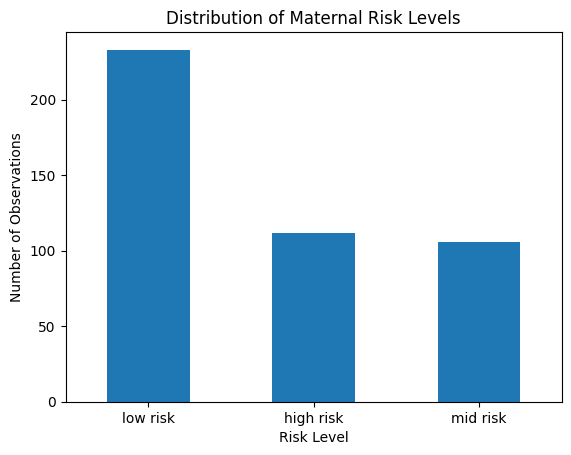

In [28]:
risk_counts = df_clean["RiskLevel"].value_counts()

risk_counts.plot(kind="bar")

plt.title("Distribution of Maternal Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.show()

### Q1 findings

Low Risk is the largest group after preprocessing, accounting for **51.7%** of the 451 observations. High Risk accounts for **24.8%**, and Mid Risk for **23.5%**. The class proportions differ noticeably from the raw file, which means repeated rows were not distributed evenly across the three labels.

There are also **35 combinations of the six predictors that are linked to more than one RiskLevel label**. These rows were kept. The disagreement may reflect clinical information that is not present in the dataset, uncertainty in the original labels, or limits in the six available predictors.

**Figure interpretation:** The bar chart shows a moderate imbalance, with Low Risk representing about half of the primary modeling sample.


## 5. Q2: How do the clinical measurements differ across risk groups?

Age, systolic and diastolic blood pressure, blood sugar, body temperature, and heart rate are compared across the three RiskLevel groups using summary statistics and boxplots.


In [29]:
risk_order = ["low risk", "mid risk", "high risk"]

In [30]:
features = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

group_summary = (
    df_clean
    .groupby("RiskLevel")[features]
    .agg(["mean", "median", "std"])
    .round(2)
    .reindex(risk_order)
)

group_summary

Age               SystolicBP  ... BodyTemp HeartRate             
            mean median    std       mean  ...      std      mean median   std
RiskLevel                                  ...                                
low risk   27.37   22.0  13.89     105.37  ...     1.11     73.04   70.0  7.02
mid risk   28.54   25.5  12.72     112.41  ...     1.47     73.90   76.0  7.00
high risk  33.73   33.5  13.57     119.49  ...     1.71     76.48   77.0  8.50

[3 rows x 18 columns]

In [31]:
mean_by_risk = (
    df_clean
    .groupby("RiskLevel")[features]
    .mean()
    .round(2)
    .reindex(risk_order)
)

mean_by_risk

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,27.37,105.37,72.72,7.20,98.36,73.04
mid risk,28.54,112.41,74.89,7.89,98.86,73.90
high risk,33.73,119.49,81.54,11.17,99.23,76.48


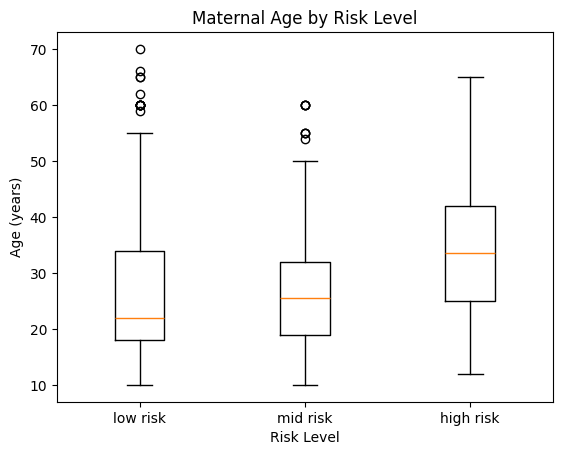

In [32]:
age_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "Age"]
    for level in risk_order
]

plt.boxplot(age_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Maternal Age by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Age (years)")

plt.show()

**Age:** The High Risk group has a higher average age, but the distributions overlap substantially. Age alone does not separate the three groups well.


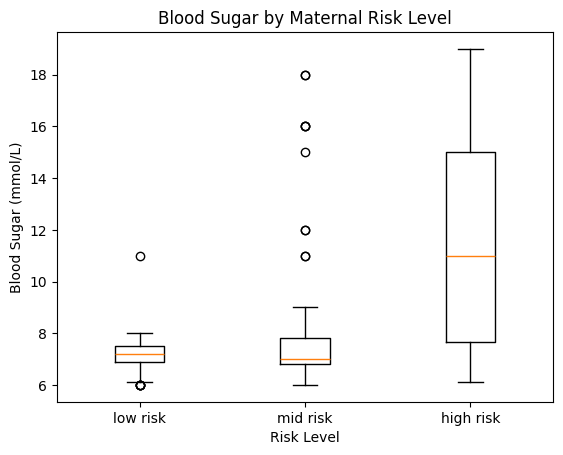

In [33]:
bs_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "BS"]
    for level in risk_order
]

plt.boxplot(bs_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Blood Sugar by Maternal Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (mmol/L)")

plt.show()

**Blood Sugar:** Blood sugar shows the clearest visual difference. A larger share of High Risk observations has elevated BS values compared with the other groups.


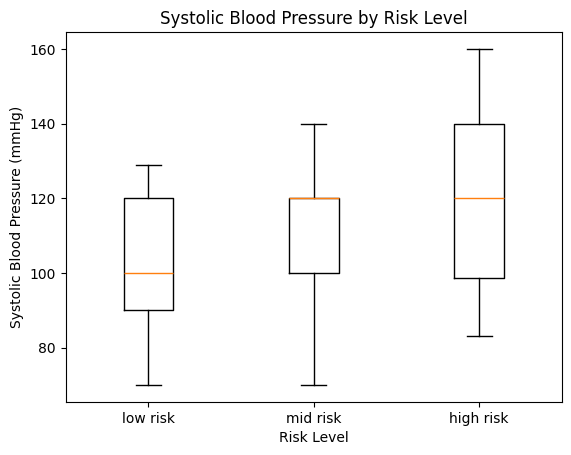

In [34]:
sbp_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "SystolicBP"]
    for level in risk_order
]

plt.boxplot(sbp_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Systolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Systolic Blood Pressure (mmHg)")

plt.show()

**Systolic blood pressure:** Systolic pressure is generally higher in the High Risk group, although the three distributions still overlap.


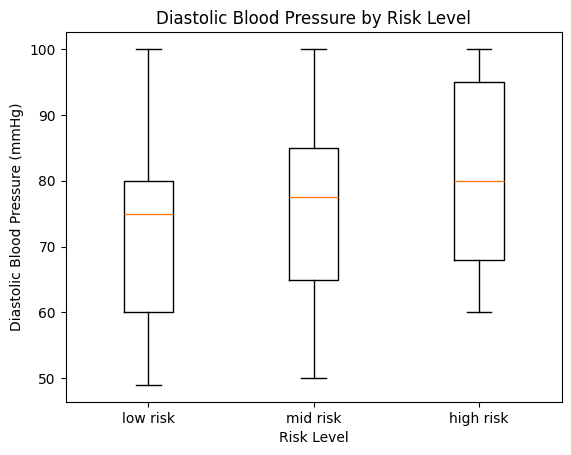

In [35]:
dbp_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "DiastolicBP"]
    for level in risk_order
]

plt.boxplot(dbp_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Diastolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Diastolic Blood Pressure (mmHg)")

plt.show()

**Diastolic blood pressure:** Diastolic pressure follows a similar pattern, with higher values in the High Risk group and considerable overlap between classes.


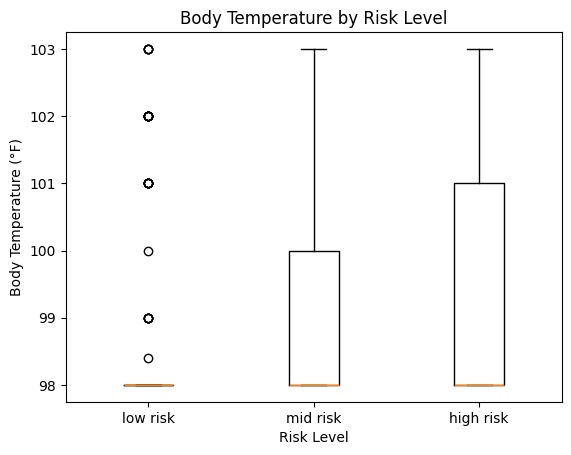

In [36]:
temp_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "BodyTemp"]
    for level in risk_order
]

plt.boxplot(temp_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Body Temperature by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Body Temperature (°F)")

plt.show()

**Body temperature:** Most observations are concentrated near 98°F. Some higher values occur in the High Risk group, but temperature provides less separation than blood sugar or blood pressure.


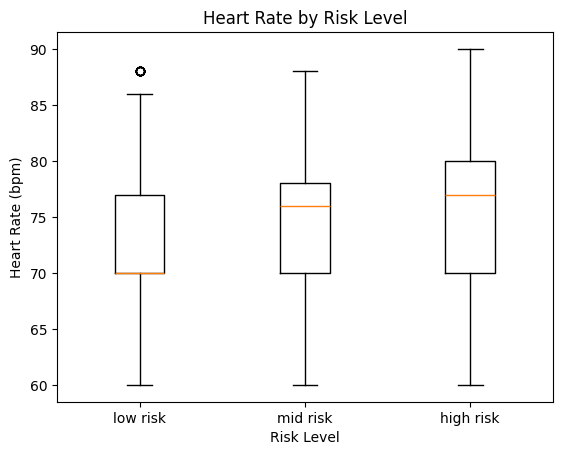

In [37]:
hr_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "HeartRate"]
    for level in risk_order
]

plt.boxplot(hr_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Heart Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Heart Rate (bpm)")

plt.show()

**Heart rate:** Heart rate differs less clearly across the three groups and shows substantial overlap.

### Q2 findings

The High Risk group has higher mean values for all six recorded measurements in this sample. The largest descriptive difference is seen in blood sugar, followed by the blood pressure measures. These comparisons describe the observed data; they do not establish causal clinical effects.


## 6. Q3: Which variables differ most for High Risk?

High Risk observations are compared with the combined Low Risk and Mid Risk observations. The predictors use different units, so raw mean differences are not directly comparable. Standardized Mean Differences, or SMDs, are used to express each difference relative to its variability.

The SMD values describe separation between groups in this dataset. They do not show that a variable causes a higher risk category.


In [38]:
df_q3 = df_clean.copy()

df_q3["HighRiskBinary"] = (
    df_q3["RiskLevel"] == "high risk"
).astype(int)

df_q3[["RiskLevel", "HighRiskBinary"]].head()

,RiskLevel,HighRiskBinary
0,high risk,1
1,high risk,1
2,high risk,1
3,high risk,1
4,low risk,0


In [39]:
high_vs_other = (
    df_q3
    .groupby("HighRiskBinary")[features]
    .mean()
    .round(2)
)

high_vs_other

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
HighRiskBinary,,,,,,
0,27.73,107.57,73.40,7.42,98.52,73.31
1,33.73,119.49,81.54,11.17,99.23,76.48


In [40]:
def standardized_mean_difference(data, feature):
    high = data.loc[
        data["RiskLevel"] == "high risk",
        feature
    ]

    other = data.loc[
        data["RiskLevel"] != "high risk",
        feature
    ]

    pooled_sd = np.sqrt(
        (
            (len(high) - 1) * high.std() ** 2
            +
            (len(other) - 1) * other.std() ** 2
        )
        /
        (len(high) + len(other) - 2)
    )

    smd = (high.mean() - other.mean()) / pooled_sd

    return smd

In [41]:
smd_results = pd.Series({
    feature: standardized_mean_difference(df_q3, feature)
    for feature in features
})

smd_results = (
    smd_results
    .abs()
    .sort_values(ascending=False)
)

smd_results

BS             1.612841
SystolicBP     0.695111
DiastolicBP    0.610591
BodyTemp       0.515447
Age            0.443053
HeartRate      0.427998
dtype: float64

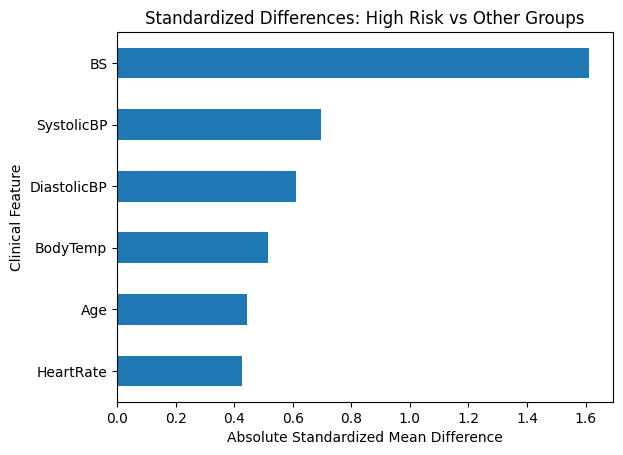

In [42]:
smd_results.sort_values().plot(kind="barh")

plt.title("Standardized Differences: High Risk vs Other Groups")
plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Clinical Feature")

plt.show()

### Q3 findings

The absolute SMD values are approximately:

- Blood Sugar: **1.61**
- Systolic Blood Pressure: **0.70**
- Diastolic Blood Pressure: **0.61**
- Body Temperature: **0.52**
- Age: **0.44**
- Heart Rate: **0.43**

Blood sugar has the largest standardized difference between High Risk and the other two groups.

**Figure interpretation:** The SMD plot puts all six variables on the same standardized scale, making the larger difference for BS easy to see.


## 7. Q4: How well does a simple baseline model classify the three risk groups?

A multinomial Logistic Regression model is used as the baseline. The 451 observations are divided into 80 percent training data and 20 percent test data. Stratification is used so that the proportions of Low Risk, Mid Risk, and High Risk remain similar in both subsets.


In [43]:
X = df_clean[features]
y = df_clean["RiskLevel"]

In [44]:
y.head()

0    high risk
1    high risk
2    high risk
3    high risk
4     low risk
Name: RiskLevel, dtype: object

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

In [46]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (360, 6)
X_test shape: (91, 6)
y_train shape: (360,)
y_test shape: (91,)


In [47]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training distribution:
RiskLevel
low risk     0.517
high risk    0.247
mid risk     0.236
Name: proportion, dtype: float64

Test distribution:
RiskLevel
low risk     0.516
high risk    0.253
mid risk     0.231
Name: proportion, dtype: float64


### Training and test split

The split contains **360 training observations** and **91 test observations**. The class proportions are very similar in the two subsets, as expected from the stratified split.


### Model pipeline

`StandardScaler` and `LogisticRegression` are fitted in one Pipeline. The scaler therefore learns its mean and standard deviation from the training data only. The test data are transformed with those training estimates, which avoids using test information during preprocessing.


In [48]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

In [49]:
_ = model.fit(X_train, y_train)


In [50]:
y_pred = model.predict(X_test)

## 8. Q5: Is accuracy enough to judge the model?

Performance is summarized with accuracy, precision, recall, F1 score, and a confusion matrix. Recall is examined separately for each class. High Risk recall receives particular attention because a High Risk observation classified as a lower risk category is an important error to identify and discuss.


In [51]:
comparison_pred = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison_pred.head(10)

,Actual,Predicted
225,low risk,low risk
406,high risk,low risk
270,low risk,low risk
449,mid risk,low risk
4,low risk,low risk
94,mid risk,mid risk
109,high risk,high risk
400,mid risk,low risk
314,mid risk,low risk
140,low risk,low risk


In [52]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))

Accuracy: 0.67


In [53]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

   high risk      0.812     0.565     0.667        23
    low risk      0.635     1.000     0.777        47
    mid risk      1.000     0.048     0.091        21

    accuracy                          0.670        91
   macro avg      0.816     0.538     0.511        91
weighted avg      0.764     0.670     0.591        91



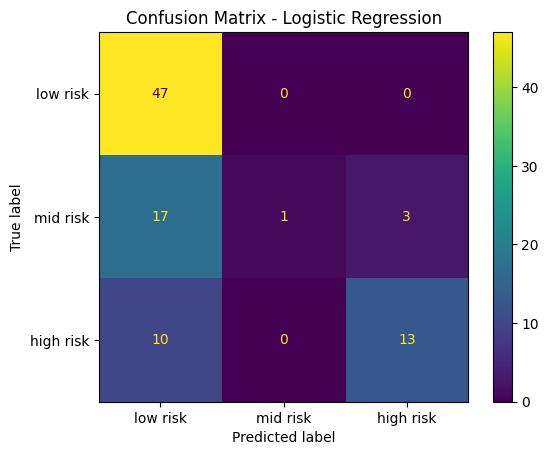

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=risk_order
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Q5 findings

The Logistic Regression model has **67.0% accuracy** on the primary test set, but the class results are very different:

- Low Risk recall: **100%**
- High Risk recall: **56.5%**
- Mid Risk recall: **4.8%**

There are 23 High Risk observations in the test set, and the model identifies 13 of them correctly. Ten are missed, so the High Risk miss rate in this split is approximately **43.5%**. Only 1 of the 21 Mid Risk observations is classified correctly.

**Figure interpretation:** The confusion matrix shows that many Mid Risk observations and several High Risk observations are assigned to Low Risk. The overall accuracy does not show this imbalance in class performance.


## 9. Q6: Where does the model make mistakes?

The test predictions are examined row by row to identify the most common error patterns. High Risk observations that were assigned to another class are reviewed separately.


In [55]:
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

results.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Actual,Predicted,Correct
225,55,120,90,6.9,98.0,76,low risk,low risk,True
406,34,110,70,7.0,98.0,80,high risk,low risk,False
270,30,120,80,7.8,98.0,70,low risk,low risk,True
449,12,100,50,6.0,98.0,70,mid risk,low risk,False
4,35,120,60,6.1,98.0,76,low risk,low risk,True


In [56]:
errors = results[results["Correct"] == False]

errors.head(20)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Actual,Predicted,Correct
406,34,110,70,7.0,98.0,80,high risk,low risk,False
449,12,100,50,6.0,98.0,70,mid risk,low risk,False
400,21,120,80,7.5,98.0,77,mid risk,low risk,False
314,30,120,75,6.8,98.0,70,mid risk,low risk,False
161,25,140,100,7.2,98.0,80,high risk,low risk,False
317,32,120,80,6.8,98.0,70,mid risk,low risk,False
130,25,120,90,6.7,101.0,80,mid risk,high risk,False
64,31,120,60,6.1,98.0,76,mid risk,low risk,False
403,13,90,65,7.5,101.0,80,high risk,low risk,False
263,60,120,80,7.8,98.0,75,high risk,low risk,False


In [57]:
error_types = (
    errors
    .groupby(["Actual", "Predicted"])
    .size()
    .sort_values(ascending=False)
)

error_types

Actual     Predicted
mid risk   low risk     17
high risk  low risk     10
mid risk   high risk     3
dtype: int64

In [58]:
missed_high = results[
    (results["Actual"] == "high risk") &
    (results["Predicted"] != "high risk")
]

missed_high

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Actual,Predicted,Correct
406,34,110,70,7.0,98.0,80,high risk,low risk,False
161,25,140,100,7.2,98.0,80,high risk,low risk,False
403,13,90,65,7.5,101.0,80,high risk,low risk,False
263,60,120,80,7.8,98.0,75,high risk,low risk,False
217,40,120,75,7.7,98.0,70,high risk,low risk,False
118,35,140,100,7.5,98.0,66,high risk,low risk,False
127,32,140,100,6.9,98.0,78,high risk,low risk,False
257,25,100,90,6.9,98.0,76,high risk,low risk,False
436,40,120,95,7.0,98.0,70,high risk,low risk,False
2,29,90,70,8.0,100.0,80,high risk,low risk,False


In [59]:
correct_high = results[
    (results["Actual"] == "high risk") &
    (results["Predicted"] == "high risk")
]

high_error_comparison = pd.DataFrame({
    "Missed High Risk": missed_high[features].mean(),
    "Correctly Identified High Risk": correct_high[features].mean()
}).round(2)

high_error_comparison

,Missed High Risk,Correctly Identified High Risk
Age,33.30,36.77
SystolicBP,117.00,124.23
DiastolicBP,84.50,84.62
BS,7.35,12.81
BodyTemp,98.50,99.08
HeartRate,75.50,80.92


### Q6 findings

The main error patterns are:

- Mid Risk predicted as Low Risk: **17 cases**
- High Risk predicted as Low Risk: **10 cases**
- Mid Risk predicted as High Risk: **3 cases**

All ten missed High Risk observations were assigned to Low Risk. Their mean BS was approximately **7.35 mmol/L**, compared with **12.81 mmol/L** among High Risk observations that were classified correctly. In this test set, High Risk observations without strongly elevated blood sugar were more difficult for the baseline model to recognize.


## 10. Q7: Which predictors contribute most to the fitted High Risk score?

The predictors were standardized before Logistic Regression was fitted, so their coefficient magnitudes can be compared more meaningfully. The coefficients describe how the fitted model uses the predictors jointly. They should not be interpreted as causal clinical effects.


In [60]:
logreg = model.named_steps["logreg"]

coef_df = pd.DataFrame(
    logreg.coef_,
    columns=features,
    index=logreg.classes_
)

coef_df.round(3)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
high risk,-0.214,0.345,0.178,1.176,0.524,0.166
low risk,0.133,-0.616,0.124,-1.276,-0.507,-0.118
mid risk,0.081,0.271,-0.302,0.100,-0.017,-0.048


In [61]:
high_risk_coef = (
    coef_df
    .loc["high risk"]
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

high_risk_coef

BS             1.176023
BodyTemp       0.524180
SystolicBP     0.344968
Age           -0.214088
DiastolicBP    0.177892
HeartRate      0.165989
Name: high risk, dtype: float64

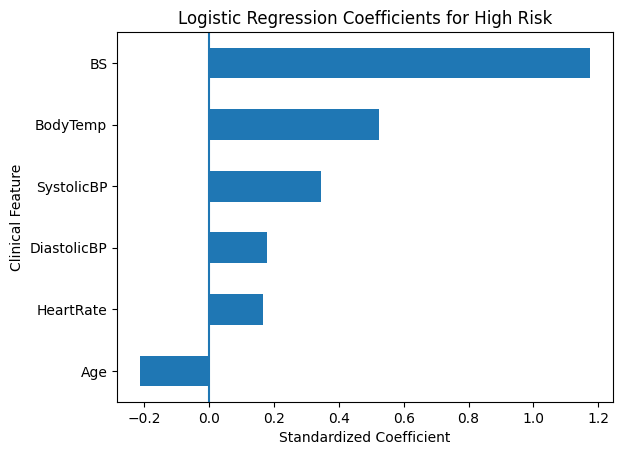

In [62]:
high_risk_coef.sort_values().plot(kind="barh")

plt.title("Logistic Regression Coefficients for High Risk")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Clinical Feature")

plt.axvline(0)

plt.show()

### Q7 findings

For High Risk, the largest standardized coefficient is for **BS (+1.176)**. The next largest positive coefficients are BodyTemp (+0.524) and SystolicBP (+0.345).

Age has a negative coefficient in the fitted model. This does not mean that older age is clinically protective. In multinomial Logistic Regression, each coefficient is estimated while the other predictors remain in the model, so its direction can be influenced by overlap and correlation among the variables.

**Figure interpretation:** The coefficient plot shows the relative contribution of the standardized predictors to the fitted High Risk score.


## 11. Sensitivity analysis for repeated observations

Repeated rows are a major feature of this dataset. The primary analysis removes them, but the lack of patient identifiers means that identical measurements cannot be confirmed as repeated records from the same person. A second analysis was therefore run to see how much this decision affects the estimated model performance.

In the sensitivity dataset, only the two observations with HeartRate equal to 7 are excluded, leaving **1,012 observations**. Repeated rows are retained. To prevent the same six predictor profile from appearing in both training and test data, identical profiles are assigned to the same fold with `StratifiedGroupKFold`.

The same Logistic Regression pipeline is fitted in each of five folds. Accuracy, Macro F1, and recall for each risk group are recorded for every fold, and their means and standard deviations are reported.


In [63]:
# Sensitivity dataset: exclude only HeartRate equal to 7.
df_sensitivity = df_raw[df_raw["HeartRate"] != 7].copy()

X_sensitivity = df_sensitivity[features]
y_sensitivity = df_sensitivity["RiskLevel"]

# Give identical predictor profiles the same group identifier.
# This keeps the same predictor profile out of both training and test data.
profile_groups = (
    df_sensitivity[features]
    .astype(str)
    .agg("|".join, axis=1)
)

group_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_results = []
profile_overlaps = []

for fold, (train_idx, test_idx) in enumerate(
    group_split.split(X_sensitivity, y_sensitivity, groups=profile_groups),
    start=1,
):
    X_train_sens = X_sensitivity.iloc[train_idx]
    X_test_sens = X_sensitivity.iloc[test_idx]
    y_train_sens = y_sensitivity.iloc[train_idx]
    y_test_sens = y_sensitivity.iloc[test_idx]

    # Check that identical predictor profiles do not cross the split.
    train_profiles = set(profile_groups.iloc[train_idx])
    test_profiles = set(profile_groups.iloc[test_idx])
    overlap = len(train_profiles.intersection(test_profiles))
    profile_overlaps.append(overlap)

    sensitivity_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000)),
    ])

    sensitivity_model.fit(X_train_sens, y_train_sens)
    y_pred_sens = sensitivity_model.predict(X_test_sens)

    fold_report = classification_report(
        y_test_sens,
        y_pred_sens,
        output_dict=True,
        zero_division=0,
    )

    fold_results.append({
        "Fold": fold,
        "Train rows": len(train_idx),
        "Test rows": len(test_idx),
        "Accuracy": accuracy_score(y_test_sens, y_pred_sens),
        "Macro F1": fold_report["macro avg"]["f1-score"],
        "High Risk Recall": fold_report["high risk"]["recall"],
        "Mid Risk Recall": fold_report["mid risk"]["recall"],
        "Low Risk Recall": fold_report["low risk"]["recall"],
        "Profile overlap": overlap,
    })

sensitivity_folds = pd.DataFrame(fold_results).set_index("Fold")

metric_columns = [
    "Accuracy",
    "Macro F1",
    "High Risk Recall",
    "Mid Risk Recall",
    "Low Risk Recall",
]

sensitivity_summary = pd.DataFrame({
    "Mean": sensitivity_folds[metric_columns].mean(),
    "SD": sensitivity_folds[metric_columns].std(ddof=1),
})

main_report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0,
)

main_vs_sensitivity = pd.DataFrame({
    "Main holdout": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": main_report["macro avg"]["f1-score"],
        "High Risk Recall": main_report["high risk"]["recall"],
        "Mid Risk Recall": main_report["mid risk"]["recall"],
    },
    "Grouped CV mean": {
        "Accuracy": sensitivity_summary.loc["Accuracy", "Mean"],
        "Macro F1": sensitivity_summary.loc["Macro F1", "Mean"],
        "High Risk Recall": sensitivity_summary.loc["High Risk Recall", "Mean"],
        "Mid Risk Recall": sensitivity_summary.loc["Mid Risk Recall", "Mean"],
    },
    "Grouped CV SD": {
        "Accuracy": sensitivity_summary.loc["Accuracy", "SD"],
        "Macro F1": sensitivity_summary.loc["Macro F1", "SD"],
        "High Risk Recall": sensitivity_summary.loc["High Risk Recall", "SD"],
        "Mid Risk Recall": sensitivity_summary.loc["Mid Risk Recall", "SD"],
    },
})

print("Maximum identical predictor profile overlap across folds:", max(profile_overlaps))
print("\nResults for each grouped fold:")
display(sensitivity_folds.round(3))

print("Grouped five fold summary (mean and sample SD):")
display(sensitivity_summary.round(3))

print("Main holdout versus grouped sensitivity analysis:")
display(main_vs_sensitivity.round(3))

Maximum identical predictor-profile overlap across folds: 0

Fold-level grouped sensitivity results:


,Train rows,Test rows,Accuracy,Macro F1,High Risk Recall,Mid Risk Recall,Low Risk Recall,Profile overlap
Fold,,,,,,,,
1,809,203,0.586,0.560,0.745,0.134,0.852,0
2,810,202,0.604,0.593,0.691,0.348,0.753,0
3,809,203,0.571,0.563,0.648,0.353,0.704,0
4,810,202,0.634,0.613,0.759,0.294,0.838,0
5,810,202,0.639,0.635,0.630,0.522,0.741,0


Grouped 5-fold summary (mean and sample SD):


,Mean,SD
Accuracy,0.607,0.029
Macro F1,0.593,0.032
High Risk Recall,0.695,0.057
Mid Risk Recall,0.330,0.139
Low Risk Recall,0.777,0.064


Main holdout versus grouped sensitivity analysis:


,Main holdout,Grouped CV mean,Grouped CV SD
Accuracy,0.670,0.607,0.029
Macro F1,0.511,0.593,0.032
High Risk Recall,0.565,0.695,0.057
Mid Risk Recall,0.048,0.330,0.139


### Sensitivity analysis results

The grouped analysis was run across all five folds. In every fold, the overlap of identical predictor profiles between training and test data was **0**.

Mean performance across the five folds was:

- Accuracy: **0.607 ± 0.029**
- Macro F1: **0.593 ± 0.032**
- High Risk recall: **0.695 ± 0.057**
- Mid Risk recall: **0.330 ± 0.139**
- Low Risk recall: **0.777 ± 0.064**

The primary holdout analysis gives accuracy **0.670**, Macro F1 **0.511**, High Risk recall **0.565**, and Mid Risk recall **0.048**. The grouped analysis therefore has lower mean accuracy, but higher mean Macro F1 and higher recall for High Risk and Mid Risk.

These results show that the estimated performance depends on how repeated observations are handled. The primary holdout result and the grouped sensitivity result should not be treated as a direct competition between models because they use different samples and different validation procedures. Without patient identifiers, neither removing nor retaining the repeated rows can be presented as definitively correct.


## 12. Q8: Interpretation and limitations

### Main findings

Blood sugar shows the largest descriptive separation for High Risk and also has the largest positive coefficient in the fitted High Risk model. Blood pressure contributes additional information, but none of the recorded measurements separates the three categories perfectly.

The primary Logistic Regression model performs unevenly across classes. It identifies Low Risk well, misses 10 of 23 High Risk observations, and performs poorly for Mid Risk. The five fold grouped analysis shows that these performance estimates also change when repeated observations are handled differently.

### Limitations

- The primary modeling dataset is small, with **451 observations**.
- Only six clinical predictors are available.
- Patient identifiers are not available, so the meaning of repeated rows cannot be verified.
- Removing repeated rows changes the observed class distribution and remains a methodological assumption.
- Some identical predictor profiles have different RiskLevel labels, suggesting ambiguity or missing clinical information.
- The primary estimate is based on one held out test set. The grouped five fold analysis gives a useful sensitivity check but is not external validation.
- The associations and fitted coefficients should not be interpreted as causal clinical effects.

### Conclusion

The value of this baseline is not the accuracy value by itself. The analysis shows why class specific recall, inspection of missed High Risk observations, careful treatment of repeated records, and transparent reporting of data limitations matter in health data analysis. The fitted Logistic Regression model is suitable for educational analysis only and should not be used as a clinical decision tool.


## 13. Reproducibility check

Before the repository is published, restart the kernel and run every cell from top to bottom with the CSV described in `data/README.md`. The random seed is fixed at 42. The grouped sensitivity analysis uses the same seed, and identical predictor profiles are kept within a single fold.
